## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance? 
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting? 
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

***Q1 Answers:***

1. Classification predicts categories or labels like healthy/not healthy, while regression predicts continuous values like price, temperature, sales. Classification uses a decision boundary to separate data into classes, while regression fits a line through continuous points to predict numerical values.

2. A confusion matrix helps us evaluate fit and understand whether we're making good or bad predictons. It is a cross tabulation of true labels with predicted ones to see if they align or not.

3. Accuracy measures the overall correctness of a model by calculating the ratio of correct predictions to the total number of inputs. It can be insufficient to evaluate a classifier's predictive performance because it fails to account for where a model predicts only majority class can achieve high accuracy whhile failing to detect crucial minority instances.

4. MSE tells us how far the predictions or the values that the model is predicting are from the true value.

5. Underfitting happens when the model is too simple to get the real pattern in the data, while overfitting happens when a model is too complex and ends up accounting for the extra noises and thus doesn't capture the underlying pattern.

6. Splitting data into training and testing sets gives us the opportunity to see how well the model is able to generalize to the new data. Choosing the k based on the test performance helps us avoid overfitting and helps with model reliability.

7. Predicting a class label is easy to intrepret but it does not showcase uncertainty. Predicting probabilities provides confidence information and gives us the likely and unlikely cases of each variable, but it does require us to choose a threshold to categorize each finding.


**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


/opt/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


<Axes: xlabel='voltage', ylabel='height'>

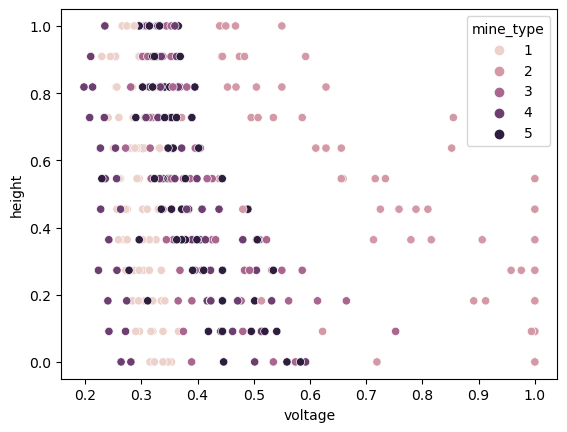

In [78]:
#1
import pandas as pd
import seaborn as sns
import numpy as np
land_mines_df = pd.read_csv("./data/land_mines.csv")

print(land_mines_df.describe())
print(land_mines_df['mine_type'].value_counts())

np.sum(land_mines_df.loc[:,].isna())

sns.scatterplot(data=land_mines_df, x="voltage", y="height", hue="mine_type")


In [79]:
#2
from sklearn.model_selection import train_test_split
def minmax(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

X = land_mines_df[['voltage', 'height', 'soil']]
y = land_mines_df['mine_type']
X = X.apply(minmax)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.5, random_state=100)

Accuracy for 3 neighbors is 0.6538461538461539
Accuracy for 5 neighbors is 0.742603550295858
Accuracy for 7 neighbors is 0.636094674556213
Accuracy for 9 neighbors is 0.5680473372781065
Accuracy for 11 neighbors is 0.5887573964497042
Accuracy for 13 neighbors is 0.5502958579881657
Accuracy for 15 neighbors is 0.5828402366863905
Accuracy for 17 neighbors is 0.5621301775147929
Accuracy for 19 neighbors is 0.5384615384615384
Accuracy for 21 neighbors is 0.5207100591715976
Accuracy for 23 neighbors is 0.5355029585798816


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


[Text(0.5, 1.0, 'Accuracy'), Text(0.5, 0, 'Neighbors')]

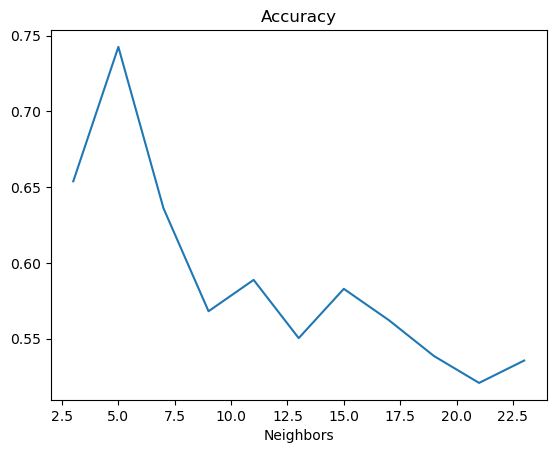

In [80]:
#3, getting k
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

k_grid = np.array([(2*k+3) for k in range(0,11)])
accuracies = []
for k in k_grid: 
    model = KNeighborsClassifier(n_neighbors = k) 
    model = model.fit(X,y) # Fit the model
    y_hat = model.predict(X) # Hard prediction
    correct = (y==y_hat).astype(int)
    
    plt.show()
    acc = model.score(X,y)
    print( f'Accuracy for {k} neighbors is {acc}')
    accuracies.append(acc)
    
sns.lineplot(x=k_grid,y=accuracies).set(title='Accuracy',xlabel='Neighbors')

In [81]:
#3 & 4

k = 5 #Chose 5 because that is where the split test accuracy peaks!
model = KNeighborsClassifier(n_neighbors = k)
model = model.fit(X_train,y_train)
y_hat = model.predict(X_test) 
print( pd.crosstab(y_test, y_hat))
print("Accuracy:",model.score(X_test,y_test))
print("More accurate for mine types of 1 and 2 and less so for 3, 4, and 5.")

col_0       1   2   3  4   5
mine_type                   
1          25   0   8  2   3
2           0  22   9  0   4
3           5   0  10  7  11
4          11   2  13  6   3
5           8   1  11  5   3
Accuracy: 0.3905325443786982
More accurate for mine types of 1 and 2 and less so for 3, 4, and 5.


***2.5:***

Even though there are many correct predictions, particularly for mine types 1 and 2, the overall accuracy is only 39%, thus quite low, meaning there is still confusion between certain mine types (3,4,5). I would advise to use this model to help out making decisions, especially for types 1 and 2, but do not let it be the end all be all. Instead of explicit classification, it would be better to make these as probabilities. Also, collecting more data would help the model gain more knowledge.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [82]:
#1

cars_df = pd.read_csv('./data/USA_cars_datasets.csv')
cars_df = cars_df.loc[:, ['price', 'year', 'mileage'],].dropna()

In [83]:
#2

def minmax(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

X = cars_df[['year', 'mileage']]
y = cars_df['price']
X = X.apply(minmax)

In [84]:
#3
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=100)

Accuracy for 3 neighbors is 0.43224943119241876
Accuracy for 10 neighbors is 0.34002161836235234
Accuracy for 25 neighbors is 0.3168200261748374
Accuracy for 50 neighbors is 0.3086300915050926
Accuracy for 100 neighbors is 0.29592974743351685
Accuracy for 200 neighbors is 0.2812162825446015
As k increases, starting from 100, the accuracy seems to increaseas well.
Our k is: 100


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

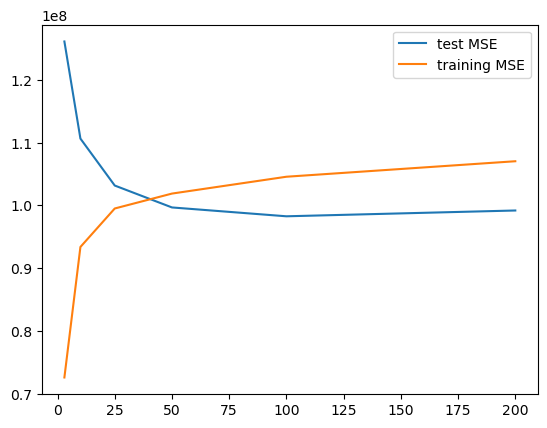

In [85]:
#4 & 5
from sklearn.neighbors import KNeighborsRegressor

def mse(y_test,y_hat):
    mse = np.sum( (y_test - y_hat) ** 2 )/len(y_test)
    return mse


k_grid = [3,10,25,50,100,200]


mses = []
mses_train = []
for k in k_grid:
    model = KNeighborsRegressor(n_neighbors = k) 
    model = model.fit(X_train,y_train)
    y_hat = model.predict(X_test)   
    mses_train.append( mse(y_train, model.predict(X_train))) # Save training MSE
    mses.append( mse(y_test, y_hat) ) # Save test MSE
    acc = model.score(X,y)
    print( f'Accuracy for {k} neighbors is {acc}')

index_star = np.argmin( mses ) 
k_star = k_grid[index_star] 
    
sns.lineplot(x=k_grid, y=mses, label = 'test MSE')
sns.lineplot(x=k_grid, y=mses_train, label = 'training MSE')
print("As k increases, starting from 100, the accuracy seems to increaseas well.")
print("Our k is:", k_star)

#6

For smaller k, the training mse is lower while the test mse is much higher. this is OVERFITTING! the model is fitting the training data too closely and not generalizing well to new data. As k is increasing, in the intermediate levels, the gap between the two gets smaller, hence the model is the best a generalizing here. For very large k, both increases, thus this means it is underfitting, due to the model becoming too smooth and predicts values closer to the overall mean price.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

In [86]:
#1

clinical_df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv').dropna()
clincial_df = clinical_df.drop('time', axis=1)

In [87]:
#2
corr_matrix = clincial_df.corr(numeric_only=True)
corr_matrix
death_matrix = clincial_df.corr(numeric_only=True)['DEATH_EVENT'].sort_values(ascending=False)
print(death_matrix)
print("The more correlated variables are serum creatinine, age, and ejection fraction")

DEATH_EVENT                 1.000000
serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603
Name: DEATH_EVENT, dtype: float64
The more correlated variables are serum creatinine, age, and ejection fraction


In [88]:
#3

dummies = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']

for col in dummies:
    print(f"\n{col}")
    print(
        clincial_df.groupby(col)['DEATH_EVENT']
        .agg(['count', 'sum', 'mean'])
    )

print("Variable `sex` has a higher proportion of the population die when it takes value 1 rather than 0.")


anaemia
         count  sum      mean
anaemia                      
0          170   50  0.294118
1          129   46  0.356589

diabetes
          count  sum      mean
diabetes                      
0           174   56  0.321839
1           125   40  0.320000

high_blood_pressure
                     count  sum      mean
high_blood_pressure                      
0                      194   57  0.293814
1                      105   39  0.371429

sex
     count  sum      mean
sex                      
0      105   34  0.323810
1      194   62  0.319588

smoking
         count  sum      mean
smoking                      
0          203   66  0.325123
1           96   30  0.312500
Variable `sex` has a higher proportion of the population die when it takes value 1 rather than 0.


As k increases, starting from 100, the accuracy seems to increaseas well.
Our k is: 17


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

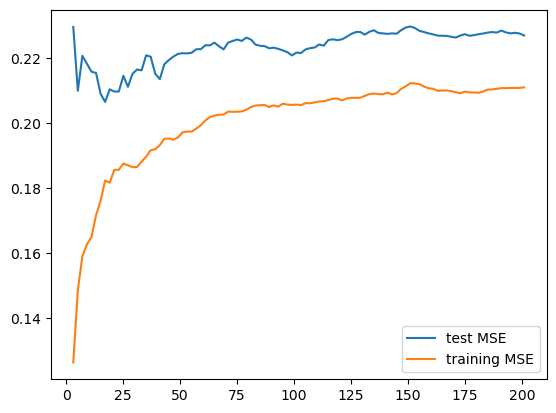

In [89]:
#4 & 5 & 6 & 7
def minmax(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

def mse(y_test,y_hat):
    mse = np.sum( (y_test - y_hat) ** 2 )/len(y_test)
    return mse

X = clincial_df[['sex', 'serum_creatinine', 'age']]
y = clinical_df['DEATH_EVENT']
X = X.apply(minmax)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=100)

k_grid = np.array([(2*k+3) for k in range(0,100)])

mses = []
mses_train = []
for k in k_grid:
    model = KNeighborsRegressor(n_neighbors = k) 
    model = model.fit(X_train,y_train)
    y_hat = model.predict(X_test)   
    mses_train.append( mse(y_train, model.predict(X_train))) 
    mses.append( mse(y_test, y_hat) )

index_star = np.argmin( mses ) 
k_star = k_grid[index_star] 
    
sns.lineplot(x=k_grid, y=mses, label = 'test MSE')
sns.lineplot(x=k_grid, y=mses_train, label = 'training MSE')
print("As k increases, starting from 100, the accuracy seems to increaseas well.")
print("Our k is:", k_star)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

As k increases, starting from 100, the accuracy seems to increaseas well.
Our k is: 13


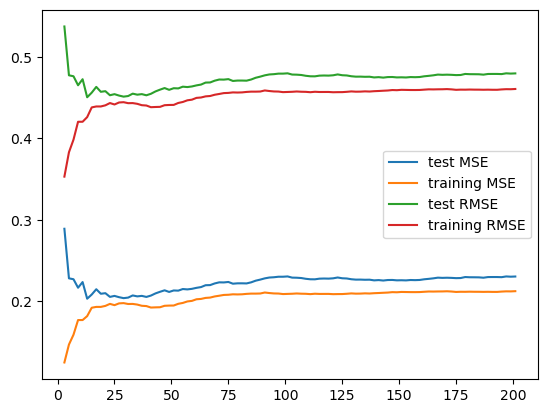

In [90]:
#8

def minmax(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

def mse(y_test,y_hat):
    mse = np.sum( (y_test - y_hat) ** 2 )/len(y_test)
    return mse

X = clincial_df[['creatinine_phosphokinase','high_blood_pressure', 'diabetes','sex', 'serum_creatinine', 'age', 'smoking', 'serum_sodium', 'platelets', 'ejection_fraction']]
y = clinical_df['DEATH_EVENT']
X = X.apply(minmax)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=100)

k_grid = np.array([(2*k+3) for k in range(0,100)])

mses = []
mses_train = []
rmses = []
rmses_train = []
for k in k_grid:
    model = KNeighborsRegressor(n_neighbors = k) 
    model = model.fit(X_train,y_train)
    y_hat = model.predict(X_test)   
    mses_train.append( mse(y_train, model.predict(X_train)))
    rmses_train.append(np.sqrt(mse(y_train, model.predict(X_train)))) 
 
    mses.append( mse(y_test, y_hat) )
    rmses.append( np.sqrt(mse(y_test, y_hat) ))


index_star = np.argmin( mses ) 
k_star = k_grid[index_star] 
    
sns.lineplot(x=k_grid, y=mses, label = 'test MSE')
sns.lineplot(x=k_grid, y=mses_train, label = 'training MSE')
sns.lineplot(x=k_grid, y=rmses, label = 'test RMSE')
sns.lineplot(x=k_grid, y=rmses_train, label = 'training RMSE')
print("As k increases, starting from 100, the accuracy seems to increaseas well.")
print("Our k is:", k_star)


#8

The model that has the best aka lower MSE would be the training MSE for all variables except 'time'.

In practice, it would preferable to use fewer variables because it helps us avoid overfitting, and we did take the variables that we feel like has the most correlation with death event. 

For RSME, the values are just transposed higher on the y-axis which makes sense because when we square root small numbers, like our MSEs which are often in the 0-point-something range, it makes the number bigger. It didn't really change the shape of our trends. 

More variable is not always better since it can often introduce extra noise that we do not need, which causes the model to overfit and not be good at generalizing to the actual underlying patterns.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on. 

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings. 
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5): 
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)